## plddt가 가장 높은 output 뽑기 

In [2]:
import os 
import json 

root_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/5grj_optimab_refine'

# 1. Unique Samples (Protein Names) 추출
# config가 아니면서 디렉토리인 것들만 대상으로 이름 추출
unique_samples = set([
    "_".join(filename.split('_')[:-3]) 
    for filename in os.listdir(root_dir) 
    if 'config' not in filename and os.path.isdir(os.path.join(root_dir, filename))
])

print(f"Detected Proteins: {unique_samples}")

# 2. 결과를 저장할 딕셔너리 초기화 (Key: 단백질 이름, Value: 빈 리스트)
result_dict = {name: [] for name in unique_samples}

# 3. 각 Mutation 디렉토리 순회
for mt_id in os.listdir(root_dir):
    if 'config' in mt_id:
        continue 
    
    mt_dir = os.path.join(root_dir, mt_id)
    
    # 디렉토리가 아닌 파일은 건너뜀
    if not os.path.isdir(mt_dir):
        continue

    plddt_dir = os.path.join(mt_dir, 'plddt')
    
    # plddt 폴더가 없는 경우 예외 처리
    if not os.path.exists(plddt_dir):
        continue

    max_h3_plddt = -float("inf")
    best_filename = None 

    # 해당 디렉토리 내에서 가장 높은 pLDDT 찾기
    for plddt_filename in os.listdir(plddt_dir):
        if not plddt_filename.endswith('.json'):
            continue

        plddt_filepath = os.path.join(plddt_dir, plddt_filename)

        with open(plddt_filepath, 'r') as f:
            plddt_data = json.load(f)
        
        h3_plddt = plddt_data['h3_bb']

        if h3_plddt > max_h3_plddt:
            max_h3_plddt = h3_plddt
            best_filename = plddt_filename
            
    # 4. 가장 높은 점수의 파일을 찾았다면 딕셔너리에 저장
    if best_filename:
        # .json 확장자 제거
        best_identifier = best_filename.replace('_plddts.json', '')
        
        # best_identifier가 어떤 unique_sample에 속하는지 확인
        matched_key = None
        for sample_name in unique_samples:
            if sample_name in best_identifier:
                matched_key = sample_name
                break # 매칭되는 키를 찾으면 중단
        
        # 매칭된 키가 있으면 리스트에 (식별자, 점수) 저장
        if matched_key:
            result_dict[matched_key].append({
                'id': best_identifier,
                'plddt': max_h3_plddt,
                'source_dir': mt_id  # 추적을 위해 원래 폴더명도 함께 저장 (선택사항)
            })
        else:
            print(f"Warning: Could not match {best_identifier} to any unique sample.")

# 결과 출력
for protein, results in result_dict.items():
    print(f"\nProtein: {protein}")
    # 점수가 높은 순으로 정렬하여 보여주기 (선택사항)
    results.sort(key=lambda x: x['plddt'], reverse=True)
    for res in results:
        print(f"  - ID: {res['id']}, H3 pLDDT: {res['plddt']:.4f}")

Detected Proteins: {'meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9', 'meta_high_var_5grj_H_L_A_WT__WT__G102S_T103S_sample_9', 'meta_high_var_5grj_H_L_A_WT__WT__K100R_G102S_sample_0', 'meta_high_var_5grj_H_L_A_WT__WT__G102S_sample_7'}

Protein: meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9
  - ID: meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9_upper_id_813_sample_1, H3 pLDDT: 93.5680
  - ID: meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9_upper_id_782_sample_0, H3 pLDDT: 93.5649
  - ID: meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9_upper_id_664_sample_5, H3 pLDDT: 93.4245
  - ID: meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9_upper_id_847_sample_5, H3 pLDDT: 92.6222
  - ID: meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9_upper_id_463_sample_9, H3 pLDDT: 92.6185
  - ID: meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9_upper_id_745_sample_1, H3 pLDDT: 92.6074
  - ID: meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9_upper_id_268_s

## 위에서 뽑은 result dict을 기반으로 높은 plddt 파일들을 별도의 디렉토리에 저장 

In [10]:
import os
import shutil
import math

# 타겟 디렉토리 설정
target_root_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/5grj_optimab_refine_high_plddt'

# 디렉토리가 없다면 생성
os.makedirs(target_root_dir, exist_ok=True)

print(f"Target Directory created at: {target_root_dir}")
print("Starting file copy process...\n")

total_copied_pdbs = 0
total_copied_jsons = 0

for protein, results in result_dict.items():
    # 1. pLDDT 점수 기준 내림차순 정렬
    results.sort(key=lambda x: x['plddt'], reverse=True)
    
    # 2. 상위 10% 개수 계산 (최소 1개는 포함하도록 올림 처리)
    # 데이터가 10개 미만이어도 1개는 복사됩니다.
    top_k_count = math.ceil(len(results) * 0.1)
    top_candidates = results[:top_k_count]
    
    print(f"[{protein}] Total: {len(results)} -> Top 10%: {len(top_candidates)} files")

    for cand in top_candidates:
        file_id = cand['id']          # 파일 식별자 (예: sample_0)
        mt_id = cand['source_dir']    # 원본 폴더명 (예: 5grj_optimab_refine_0)
        
        # 원본 파일 경로 구성
        # 1) PDB 파일 경로 추정 (mt_dir 바로 아래에 있다고 가정)
        src_pdb_path = os.path.join(root_dir, mt_id, f"{file_id}.pdb")
        
        # 2) JSON 파일 경로 추정 (mt_dir/plddt/ 아래, _plddts.json 형태라고 가정)
        # 이전 코드 로직에 따라 _plddts.json이 원본 파일명임
        src_json_path = os.path.join(root_dir, mt_id, 'plddt', f"{file_id}_plddts.json")
        
        # 복사 수행 (PDB)
        if os.path.exists(src_pdb_path):
            try:
                shutil.copy2(src_pdb_path, target_root_dir)
                total_copied_pdbs += 1
            except Exception as e:
                print(f"  Error copying PDB {file_id}: {e}")
        else:
            print(f"  Warning: PDB not found for {file_id} at {src_pdb_path}")

        # 복사 수행 (JSON)
        if os.path.exists(src_json_path):
            try:
                shutil.copy2(src_json_path, target_root_dir)
                total_copied_jsons += 1
            except Exception as e:
                print(f"  Error copying JSON {file_id}: {e}")
        else:
            # 혹시 파일명이 _plddt.json (단수형)일 경우를 대비한 예외처리
            src_json_path_alt = os.path.join(root_dir, mt_id, 'plddt', f"{file_id}_plddt.json")
            if os.path.exists(src_json_path_alt):
                shutil.copy2(src_json_path_alt, target_root_dir)
                total_copied_jsons += 1
            else:
                print(f"  Warning: JSON not found for {file_id}")

print("-" * 50)
print(f"Process Completed.")
print(f"Total PDBs copied: {total_copied_pdbs}")
print(f"Total JSONs copied: {total_copied_jsons}")
print(f"Files are located in: {target_root_dir}")

Target Directory created at: /home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/5grj_optimab_refine_high_plddt
Starting file copy process...

[meta_high_var_5grj_H_L_A_WT__WT__K100R_G102S_sample_0] Total: 100 -> Top 10%: 10 files
[meta_high_var_5grj_H_L_A_WT__WT__G102S_sample_7] Total: 100 -> Top 10%: 10 files
[meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9] Total: 100 -> Top 10%: 10 files
[meta_high_var_5grj_H_L_A_WT__WT__G102S_T103S_sample_9] Total: 100 -> Top 10%: 10 files
--------------------------------------------------
Process Completed.
Total PDBs copied: 40
Total JSONs copied: 40
Files are located in: /home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.2_stage_3_confidence_only_plddt/2025-12-12_09-21-35/epoch=27-step=40124/5grj_optimab_refine_high_plddt


## CDRFlow plddt 변화 시각화하기 

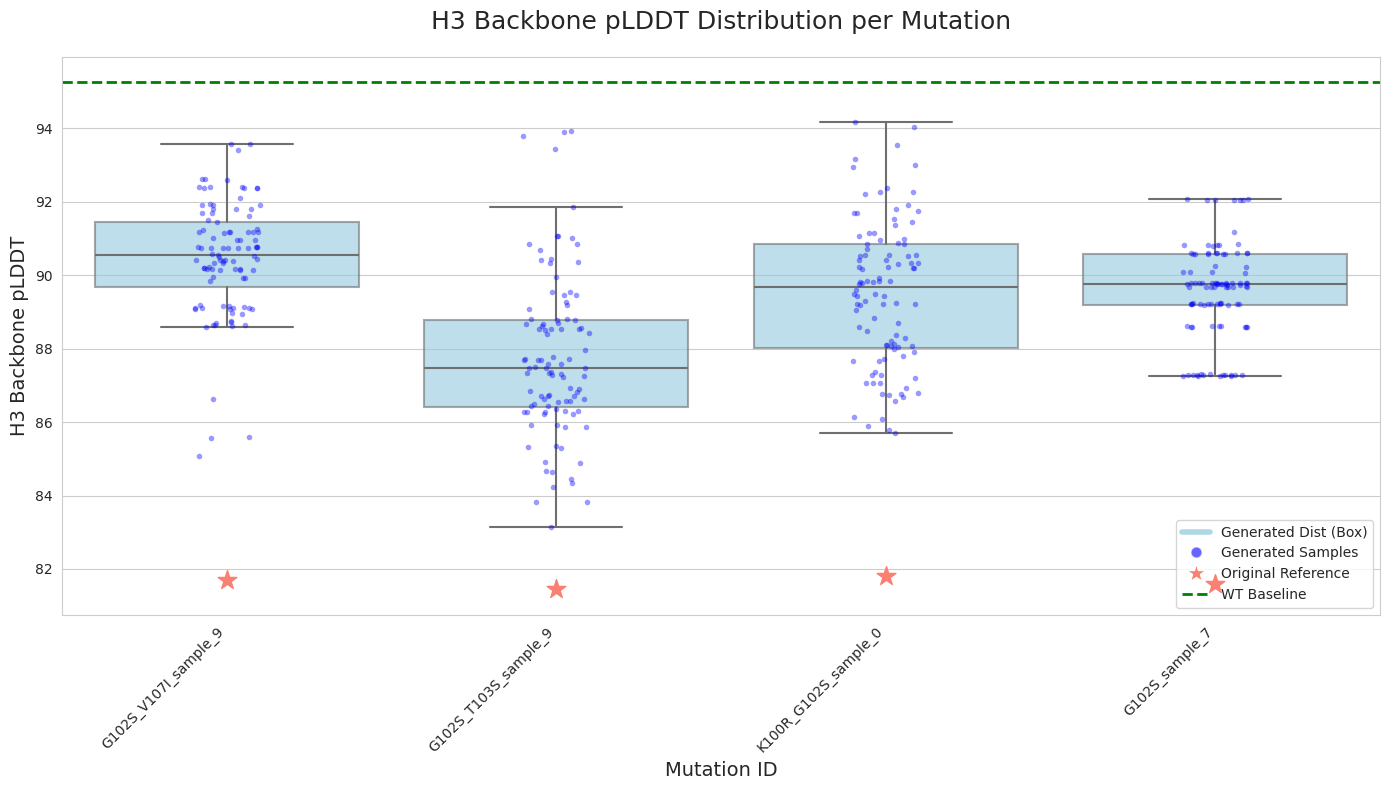

In [10]:
import os 

h3_bb_plddt_ori = {
    "meta_high_var_5grj_H_L_A_WT__WT__G102S_V107I_sample_9": 81.693,
    "meta_high_var_5grj_H_L_A_WT__WT__G102S_T103S_sample_9": 81.445,
    "meta_high_var_5grj_H_L_A_WT__WT__K100R_G102S_sample_0": 81.822,
    "meta_high_var_5grj_H_L_A_WT__WT__G102S_sample_7": 81.603,
    "meta_high_var_5grj_H_L_A_WT__WT__WT": 95.261
}

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

# --- 1. 데이터 전처리 ---

# (1) result_dict를 DataFrame으로 변환
# result_dict 구조: { 'protein_name': [ {'id': ..., 'plddt': ...}, ... ] }
plot_data = []

for protein_name, items in result_dict.items():
    for item in items:
        # 파일명(ID)에서 Mutation 부분만 추출하여 라벨로 사용 (선택 사항)
        # 예: ..._WT__WT__G102S -> G102S
        # 정규식을 써서 WT__WT__ 뒤에 오는 부분을 잡거나, 전체 ID를 그대로 사용해도 됩니다.
        # 여기서는 전체 ID가 너무 길 수 있으므로, 식별 가능한 뒷부분(Mutation ID)만 추출해보겠습니다.
        
        # 간단하게 전체 ID를 사용하거나, 사용자가 원하는 포맷으로 변경 가능
        # 여기서는 h3_bb_plddt_ori의 키와 매칭을 위해 전체 ID(item['id']) 대신
        # result_dict의 key인 protein_name이나, item['id']를 적절히 가공해야 합니다.
        
        # 문제 조건: "result_dict의 keys와 h3_bb_plddt_ori의 keys (WT 제외)는 서로 동일해"
        # 하지만 result_dict의 값들은 리스트이므로, 해당 리스트가 속한 그룹(key)이 x축 라벨이 되어야 함.
        
        plot_data.append({
            'Mutation Group': protein_name,  # X축 기준 (h3_bb_plddt_ori의 키와 대응)
            'pLDDT': item['plddt'],
            'Type': 'Generated'
        })

df = pd.DataFrame(plot_data)

# (2) h3_bb_plddt_ori 데이터 정리
# WT는 기준선으로 그리고, 나머지는 비교 점으로 추가
wt_score = h3_bb_plddt_ori.get("meta_high_var_5grj_H_L_A_WT__WT__WT")
original_points = []

for key, score in h3_bb_plddt_ori.items():
    if key == "meta_high_var_5grj_H_L_A_WT__WT__WT":
        continue # WT는 따로 처리
    
    # result_dict의 키와 매칭되는지 확인 (문자열 포함 관계 등)
    # 질문 내용상 result_dict의 key와 h3_bb_plddt_ori의 key가 직접 대응된다고 가정
    original_points.append({
        'Mutation Group': key,
        'pLDDT': score,
        'Type': 'Original'
    })

df_ori = pd.DataFrame(original_points)


# --- 2. 시각화 (Boxplot + Stripplot + Reference Marker) ---

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# (1) Boxplot 그리기 (Generated Samples 분포)
ax = sns.boxplot(
    data=df,
    x='Mutation Group',
    y='pLDDT',
    color='skyblue',  # 단일 색상 또는 palette 사용 가능
    showfliers=False,   # 이상치 점 숨기기 (stripplot으로 그릴 예정)
    boxprops={'alpha': 0.6}
)

# (2) Stripplot 그리기 (Generated Samples 개별 점)
sns.stripplot(
    data=df,
    x='Mutation Group',
    y='pLDDT',
    color='blue',
    alpha=0.4,
    size=4,
    jitter=True
)

# (3) Original 값 (h3_bb_plddt_ori) 표시
# x축 순서가 섞일 수 있으므로, 현재 x축의 라벨 순서를 가져와서 매핑
labels = [item.get_text() for item in ax.get_xticklabels()]

# 각 라벨 위치에 맞는 Original 값을 찾아 빨간색 별로 표시
for i, label in enumerate(labels):
    # 해당 라벨(Mutation Group)에 해당하는 Original 점 찾기
    match = df_ori[df_ori['Mutation Group'] == label]
    if not match.empty:
        plt.scatter(
            x=i, 
            y=match['pLDDT'].values[0], 
            color='salmon', 
            marker='*', 
            s=200, 
            zorder=10, 
            label='Original Ref' if i == 0 else "" # 범례는 한 번만 추가
        )

# (4) WT 기준선 추가 (점선)
if wt_score:
    plt.axhline(y=wt_score, color='green', linestyle='--', linewidth=2, label=f'WT Score ({wt_score:.2f})')

# --- 3. 스타일 및 라벨 설정 ---

plt.title('H3 Backbone pLDDT Distribution per Mutation', fontsize=18, pad=20)
plt.xlabel('Mutation ID', fontsize=14)
plt.ylabel('H3 Backbone pLDDT', fontsize=14)

# X축 라벨 가독성을 위해 회전 및 포맷팅 (너무 길 경우 일부만 표시하는 로직 추가 가능)
# 예: "meta_high_var_5grj_H_L_A_WT__WT__" 제거
formatted_labels = [label.split("WT__WT__")[-1] if "WT__WT__" in label else label for label in labels]
ax.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=10)

# 범례 설정 (커스텀 범례 생성)
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='lightblue', lw=4, label='Generated Dist (Box)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, alpha=0.6, label='Generated Samples'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='salmon', markersize=15, label='Original Reference'),
    Line2D([0], [0], color='green', linestyle='--', lw=2, label='WT Baseline')
]
plt.legend(handles=custom_lines, loc='lower right')

plt.tight_layout()
plt.show()